# Durak Autoresearch Experiment Analysis

Analysis of autonomous heuristic-search results from `results.tsv` — the Durak
local-heuristics vs memory-baseline loop (`program.md`).

**Run:** execute all cells in this notebook, or from the repo root:

```bash
jupyter nbconvert --execute analysis.ipynb
```

Writes `progress.png` (point_rate + search_score over time), `occam.png`, and
`score_alignment.png`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RESULTS_PATH = Path("results.tsv")
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        "results.tsv not found. Run the autoresearch loop first (see program.md)."
    )

# Durak schema: commit, opponent, point_rate, search_score, lower_ci, games, complexity, status, description
df = pd.read_csv(RESULTS_PATH, sep="\t", dtype=str)
for col in ("point_rate", "search_score", "lower_ci", "games", "complexity"):
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["status"] = df["status"].str.strip().str.lower()
df["opponent"] = df["opponent"].str.strip()
df["commit"] = df["commit"].str.strip()

# Headline rows: B2 vs B4 (one ladder eval per commit / probe)
b4 = df[df["opponent"] == "B4"].copy().reset_index(drop=True)
b4["exp_id"] = np.arange(len(b4))

print(f"Total rows: {len(df)}  |  B4 headline rows: {len(b4)}")
print(f"Columns: {list(df.columns)}")
b4.head(10)

Total rows: 556  |  B4 headline rows: 546
Columns: ['commit', 'opponent', 'point_rate', 'search_score', 'lower_ci', 'games', 'complexity', 'status', 'description']


,commit,opponent,point_rate,search_score,lower_ci,games,complexity,status,description,exp_id
0,228791f,B4,0.49211,0.68404,0.49200,10000000,310,keep,baseline B2 H1-H3,0
1,2415f53,B4,0.50461,0.70002,0.50447,10000000,210,keep,exp A: drop H3 same-rank trump defense,1
2,35330ec,B4,0.52434,0.72562,0.52409,10000000,100,keep,exp B: drop H2 group-attack H1-only,2
3,c263a3a,B4,0.53748,0.73239,0.53723,10000000,100,keep,exp G: endgame open low pair singleton,3
4,84c9321,B4,0.54507,0.73650,0.54485,10000000,100,keep,exp H: midgame pair-open + endgame trump-strip,4
5,069959b,B4,0.54516,0.73654,0.54493,10000000,100,discard,exp J: void-suit pile pressure (below keep bar),5
6,probe,B4,0.53397,0.73094,0.53241,200000,100,discard,exp K: defense voluntary take (quick regression),6
7,probe,B4,0.54409,0.73727,0.54246,200000,100,discard,exp L: relaxed trump-strip opp<=4 (quick),7
8,probe,B4,0.54551,0.73679,0.54391,200000,100,discard,exp M: late pair-open deck<=6 (quick neutral),8
9,f36cda7,B4,0.54714,0.73689,0.54691,10000000,100,keep,exp P: void pile -8 + finish trump-strip open,9


In [2]:
counts = b4["status"].value_counts()
print("B4 headline experiment outcomes:")
print(counts.to_string())

n_keep = int(counts.get("keep", 0))
n_discard = int(counts.get("discard", 0))
n_crash = int(counts.get("crash", 0))
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

# Ablation rows (if any)
ablate = df[df["opponent"] == "B3vsB2"]
if len(ablate):
    print("\nMemory ablation (B3 vs B2):")
    for _, row in ablate.iterrows():
        print(
            f"  {row['commit']}  point_rate={float(row['point_rate']):.5f}  "
            f"memory_value≈{float(row['point_rate']) - 0.5:.5f}  {row['description']}"
        )

B4 headline experiment outcomes:
status
discard    526
keep        20

Keep rate: 20/546 = 3.7%

Memory ablation (B3 vs B2):
  f5bb135  point_rate=0.50000  memory_value≈0.00000  WR post-plateau memory ablation batch-114
  ab2d08c  point_rate=0.49920  memory_value≈-0.00080  exp ZN memory ablation: defense shape uses no memory (jun25 b1)
  310bc72  point_rate=0.49915  memory_value≈-0.00085  exp ZW memory ablation: conservation take uses no memory (jun25 b2)
  8487eb7  point_rate=0.50000  memory_value≈0.00000  exp QA memory ablation: identical play, memory fully inert (jun25 b3)


In [3]:
kept = b4[b4["status"] == "keep"].copy()
print(f"KEPT B4 experiments ({len(kept)} total):\n")
for _, row in kept.iterrows():
  print(
      f"  {row['commit']}  point_rate={row['point_rate']:.5f}  "
      f"search={row['search_score']:.5f}  complexity={int(row['complexity'])}  "
      f"{row['description']}"
  )

KEPT B4 experiments (20 total):

  228791f  point_rate=0.49211  search=0.68404  complexity=310  baseline B2 H1-H3
  2415f53  point_rate=0.50461  search=0.70002  complexity=210  exp A: drop H3 same-rank trump defense
  35330ec  point_rate=0.52434  search=0.72562  complexity=100  exp B: drop H2 group-attack H1-only
  c263a3a  point_rate=0.53748  search=0.73239  complexity=100  exp G: endgame open low pair singleton
  84c9321  point_rate=0.54507  search=0.73650  complexity=100  exp H: midgame pair-open + endgame trump-strip
  f36cda7  point_rate=0.54714  search=0.73689  complexity=100  exp P: void pile -8 + finish trump-strip open
  7bb300c  point_rate=0.55749  search=0.74418  complexity=100  exp Q: finish pile low-trump dump endgame
  41b5857  point_rate=0.56543  search=0.74988  complexity=100  exp R: finish mode opp<=3
  65e8104  point_rate=0.58063  search=0.75452  complexity=100  exp S: finish trump dump >=1 trump
  f6b5d93  point_rate=0.58560  search=0.75736  complexity=100  exp V: pi

## Point rate vs B4 (reporting metric)

Track how `point_rate(B2 vs B4)` and `search_score` evolve. Higher is better.
The running maximum shows the frontier — best result achieved so far.

WR keep exp_id=466.0; jun25 (Opus 4.8 max) starts at exp_id=515.0


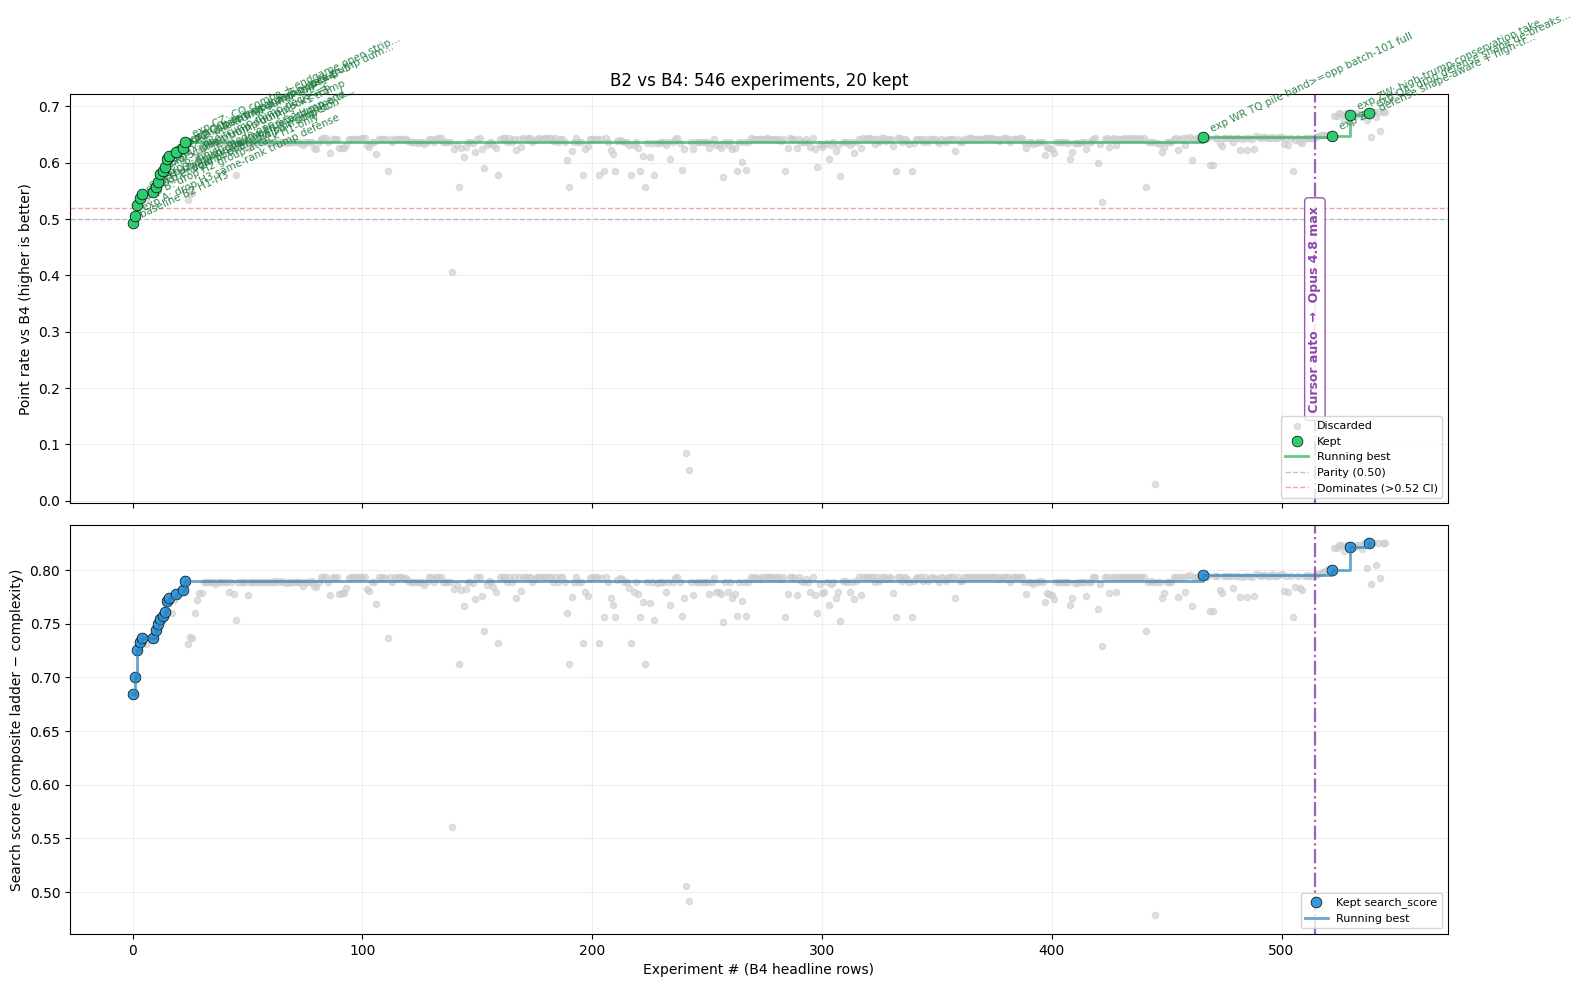

Saved to progress.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

valid = b4[b4["status"] != "crash"].copy()

# --- Top: point_rate vs B4 ---
ax = axes[0]
disc = valid[valid["status"] == "discard"]
ax.scatter(disc["exp_id"], disc["point_rate"], c="#cccccc", s=20, alpha=0.6, label="Discarded")
kept_v = valid[valid["status"] == "keep"]
ax.scatter(
    kept_v["exp_id"], kept_v["point_rate"], c="#2ecc71", s=60, zorder=4,
    label="Kept", edgecolors="black", linewidths=0.5,
)
if len(kept_v):
    running_max = kept_v["point_rate"].cummax()
    ax.step(kept_v["exp_id"], running_max, where="post", color="#27ae60",
            linewidth=2, alpha=0.7, label="Running best")
    for _, row in kept_v.iterrows():
        desc = str(row["description"]).strip()
        if len(desc) > 40:
            desc = desc[:37] + "..."
        ax.annotate(desc, (row["exp_id"], row["point_rate"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7.5,
                    color="#1a7a3a", alpha=0.9, rotation=25, ha="left")
ax.axhline(0.50, color="#888", linestyle="--", linewidth=1, alpha=0.5, label="Parity (0.50)")
ax.axhline(0.52, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.5, label="Dominates (>0.52 CI)")
ax.set_ylabel("Point rate vs B4 (higher is better)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_title(f"B2 vs B4: {len(b4)} experiments, {len(kept_v)} kept")

# --- Bottom: search_score ---
ax2 = axes[1]
ax2.scatter(disc["exp_id"], disc["search_score"], c="#cccccc", s=20, alpha=0.6)
ax2.scatter(kept_v["exp_id"], kept_v["search_score"], c="#3498db", s=60,
            edgecolors="black", linewidths=0.5, label="Kept search_score")
if len(kept_v):
    ax2.step(kept_v["exp_id"], kept_v["search_score"].cummax(), where="post",
             color="#2980b9", linewidth=2, alpha=0.7, label="Running best")
ax2.set_xlabel("Experiment # (B4 headline rows)")
ax2.set_ylabel("Search score (composite ladder − complexity)")
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(True, alpha=0.2)

# --- model authorship divider: Cursor auto (jun22 & earlier) -> Opus 4.8 max (jun25) ---
_jun25 = b4[b4["description"].fillna("").str.contains("jun25", case=False)]
_boundary = float(_jun25["exp_id"].min()) if len(_jun25) else None
_wr = b4[(b4["commit"] == "f5bb135") & (b4["status"] == "keep")]
_wr_id = float(_wr["exp_id"].iloc[0]) if len(_wr) else None
if _boundary is not None:
    for _a in (ax, ax2):
        _a.axvline(_boundary - 0.5, color="#8e44ad", linestyle="-.", linewidth=1.6, alpha=0.85)
    ax.text(_boundary - 0.5, 0.34, " Cursor auto  \u2192  Opus 4.8 max ", rotation=90,
            color="#8e44ad", fontsize=9, ha="center", va="center", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#8e44ad", alpha=0.9))
    print(f"WR keep exp_id={_wr_id}; jun25 (Opus 4.8 max) starts at exp_id={_boundary}")

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary statistics

In [5]:
kept_b4 = b4[b4["status"] == "keep"].copy()
if len(b4) == 0:
    print("No B4 rows yet.")
else:
    baseline_pr = float(b4.iloc[0]["point_rate"])
    baseline_search = float(b4.iloc[0]["search_score"])
    best_pr = float(kept_b4["point_rate"].max()) if len(kept_b4) else baseline_pr
    best_search = float(kept_b4["search_score"].max()) if len(kept_b4) else baseline_search
    best_row = kept_b4.loc[kept_b4["point_rate"].idxmax()] if len(kept_b4) else b4.iloc[0]

    print(f"Baseline point_rate vs B4:  {baseline_pr:.5f}")
    print(f"Best point_rate vs B4:      {best_pr:.5f}  (Δ {best_pr - baseline_pr:+.5f})")
    print(f"Baseline search_score:      {baseline_search:.5f}")
    print(f"Best search_score:          {best_search:.5f}  (Δ {best_search - baseline_search:+.5f})")
    print(f"Best experiment:            {best_row['description']}")
    print(f"Best complexity:            {int(best_row['complexity'])}")
    print()

    # Ladder at best kept commit
    best_commit = best_row["commit"]
    ladder = df[df["commit"] == best_commit]
    print(f"Ladder at best commit {best_commit}:")
    for opp in ["B4", "B1", "B0", "B3vsB2"]:
        rows = ladder[ladder["opponent"] == opp]
        if len(rows):
            r = rows.iloc[0]
            print(f"  vs {opp:6s}  point_rate={float(r['point_rate']):.5f}  lower_ci={float(r['lower_ci']):.5f}")

Baseline point_rate vs B4:  0.49211
Best point_rate vs B4:      0.68903  (Δ +0.19692)
Baseline search_score:      0.68404
Best search_score:          0.82464  (Δ +0.14060)
Best experiment:            exp QA: drop defense shape tie-breaks + take rank>=2 (jun25 b3 full)
Best complexity:            100

Ladder at best commit 8487eb7:
  vs B4      point_rate=0.68903  lower_ci=0.68877
  vs B1      point_rate=0.97519  lower_ci=0.97510
  vs B0      point_rate=0.98782  lower_ci=0.98775
  vs B3vsB2  point_rate=0.50000  lower_ci=0.50000


## Top hits (kept experiments by improvement vs previous keep)

In [6]:
kept_b4 = b4[b4["status"] == "keep"].copy()
if len(kept_b4) < 2:
    print("Need at least 2 kept experiments for deltas.")
else:
    kept_b4 = kept_b4.copy()
    kept_b4["prev_pr"] = kept_b4["point_rate"].shift(1)
    kept_b4["delta_pr"] = kept_b4["point_rate"] - kept_b4["prev_pr"]
    hits = kept_b4.iloc[1:].sort_values("delta_pr", ascending=False)

    print(f"{'Rank':>4}  {'Δ point_rate':>12}  {'point_rate':>10}  {'search':>8}  {'complexity':>10}  Description")
    print("-" * 100)
    for rank, (_, row) in enumerate(hits.iterrows(), 1):
        print(
            f"{rank:4d}  {row['delta_pr']:+.5f}      {row['point_rate']:.5f}  "
            f"{row['search_score']:.5f}  {int(row['complexity']):10d}  {row['description']}"
        )
    print(f"\n{'':>4}  {hits['delta_pr'].sum():+.5f}      {'':>10}  {'':>8}  TOTAL vs baseline keep")

Rank  Δ point_rate  point_rate    search  complexity  Description
----------------------------------------------------------------------------------------------------
   1  +0.03689      0.68494  0.82176         100  exp ZW: high-trump conservation take widened rank>=3 deck>=5 any pile (jun25 b2 full)
   2  +0.01973      0.52434  0.72562         100  exp B: drop H2 group-attack H1-only
   3  +0.01547      0.60708  0.77075         100  exp AC: pile trump dump opp<=4
   4  +0.01520      0.58063  0.75452         100  exp S: finish trump dump >=1 trump
   5  +0.01314      0.53748  0.73239         100  exp G: endgame open low pair singleton
   6  +0.01250      0.50461  0.70002         210  exp A: drop H3 same-rank trump defense
   7  +0.01041      0.63676  0.78941         100  exp CZ: CQ combo + endgame open strip opp<=2
   8  +0.01035      0.55749  0.74418         100  exp Q: finish pile low-trump dump endgame
   9  +0.00813      0.64489  0.79506         100  exp WR TQ pile hand>=opp batch

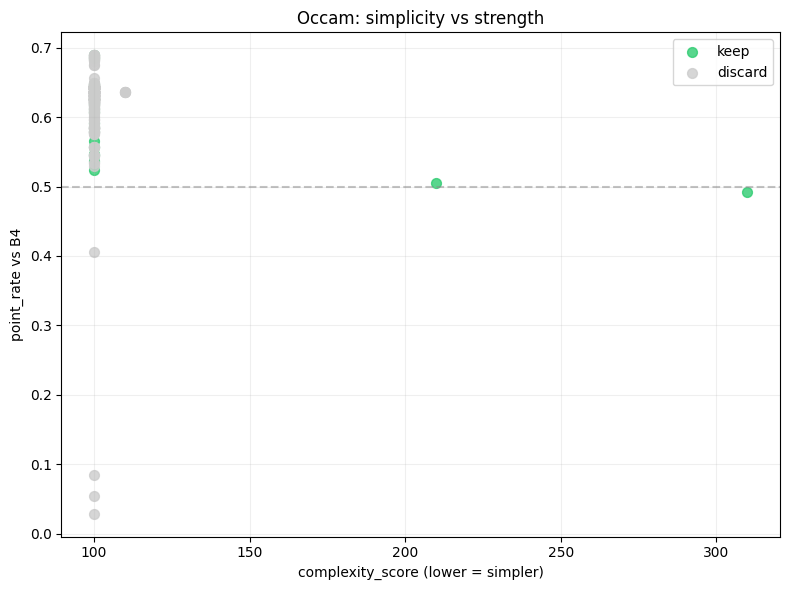

Saved to occam.png


In [7]:
# Complexity vs point_rate (Occam view): did simplification help?
fig, ax = plt.subplots(figsize=(8, 6))
for status, color, label in [
    ("keep", "#2ecc71", "keep"),
    ("discard", "#cccccc", "discard"),
]:
    sub = b4[b4["status"] == status]
    ax.scatter(sub["complexity"], sub["point_rate"], c=color, s=50, alpha=0.8, label=label)
ax.set_xlabel("complexity_score (lower = simpler)")
ax.set_ylabel("point_rate vs B4")
ax.set_title("Occam: simplicity vs strength")
ax.axhline(0.50, color="#888", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("occam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to occam.png")

## Feedback-loop diagnostics

These cells analyze whether the research loop itself is improving:

- keep rate
- crash rate
- full-eval hit rate
- average complexity of kept vs discarded variants
- B4/search-score divergence
- repeated descriptions / repeated failed directions

In [8]:
from collections import Counter
import re

if len(b4) == 0:
    print('No B4 rows yet.')
else:
    print('Feedback-loop diagnostics')
    print('-' * 32)

    counts = b4['status'].value_counts()
    total = len(b4)
    keeps = int(counts.get('keep', 0))
    discards = int(counts.get('discard', 0))
    crashes = int(counts.get('crash', 0))
    decided = keeps + discards

    print(f'Total B4 attempts: {total}')
    print(f'Keeps:             {keeps}')
    print(f'Discards:          {discards}')
    print(f'Crashes:           {crashes}')

    if decided:
        print(f'Keep rate:         {keeps / decided:.1%}')

    valid = b4[b4['status'] != 'crash'].copy()
    if len(valid):
        print()
        print(f'Mean B4 point_rate:      {valid["point_rate"].mean():.5f}')
        print(f'Mean search_score:       {valid["search_score"].mean():.5f}')
        print(f'Mean complexity:         {valid["complexity"].mean():.1f}')

    kept_rows = b4[b4['status'] == 'keep']
    discarded_rows = b4[b4['status'] == 'discard']

    if len(kept_rows) and len(discarded_rows):
        print()
        print(f'Kept mean complexity:    {kept_rows["complexity"].mean():.1f}')
        print(f'Discard mean complexity: {discarded_rows["complexity"].mean():.1f}')

    desc = b4['description'].fillna('').astype(str).str.lower()
    tokens = []
    for item in desc:
        tokens.extend(re.findall(r'[a-zA-Z_]{4,}', item))

    common = Counter(tokens).most_common(20)
    print()
    print('Common description tokens:')
    for token, n in common:
        print(f'  {token:24s} {n}')

Feedback-loop diagnostics
--------------------------------
Total B4 attempts: 546
Keeps:             20
Discards:          526
Crashes:           0
Keep rate:         3.7%

Mean B4 point_rate:      0.62870
Mean search_score:       0.78355
Mean complexity:         100.7

Kept mean complexity:    116.0
Discard mean complexity: 100.1

Common description tokens:
  batch                    324
  deck                     197
  pile                     155
  pair                     121
  trump                    118
  strip                    80
  open                     67
  medium                   64
  void                     61
  rank                     58
  only                     54
  combo                    46
  total                    45
  ablate                   44
  quick                    40
  defense                  38
  hand                     35
  take                     34
  pass                     32
  sweep                    32


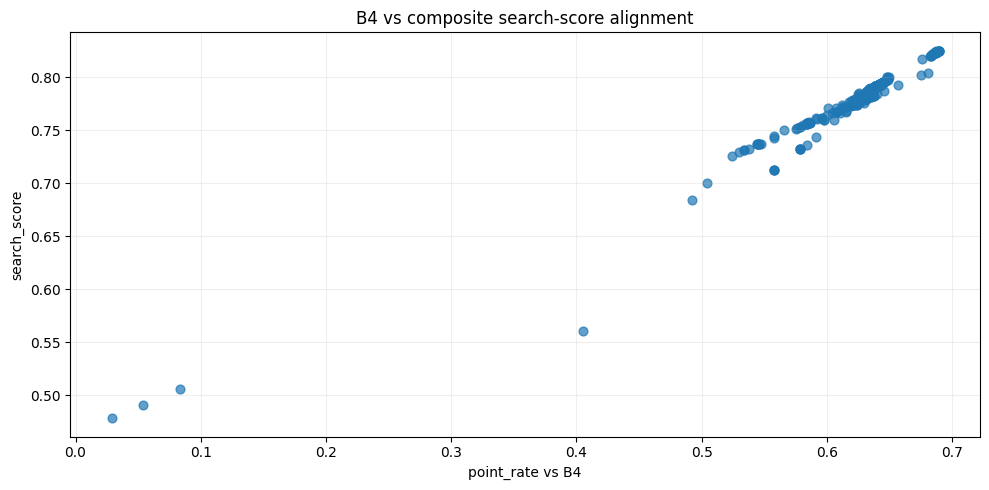

Saved to score_alignment.png


In [9]:
valid = b4[b4['status'] != 'crash'].copy()

if len(valid):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(valid['point_rate'], valid['search_score'], s=40, alpha=0.7)
    ax.set_xlabel('point_rate vs B4')
    ax.set_ylabel('search_score')
    ax.set_title('B4 vs composite search-score alignment')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('score_alignment.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to score_alignment.png')
else:
    print('No valid rows to plot.')